# 01 — Sentinel-2 数据下载
**数据源：Microsoft Planetary Computer**

本笔记本从 Planetary Computer 下载 NSW 测试区的 Sentinel-2 L2A 影像，
计算 NDVI、NDWI、BSI、SAVI 四个指数，并保存为 GeoTIFF。

测试区：悉尼西部农业区（147°E–149°E，34°S–32.5°S）
时间段：2022年1月

## 1. 导入包

In [28]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 修复中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pystac_client import Client
import planetary_computer as pc
import stackstac
import rasterio
from rasterio.transform import from_bounds

from src.data_utils import load_config, ensure_dir, print_array_info
from src.indices import calculate_all_indices

print('所有包导入成功')

所有包导入成功


## 2. 加载配置

In [19]:
cfg = load_config('../configs/config.yaml')

# 使用测试小区域
bbox = cfg['region']['bbox_test']
BBOX = [bbox['lon_min'], bbox['lat_min'], bbox['lon_max'], bbox['lat_max']]

TIME_RANGE = '2026-04-01/2026-05-01'
CLOUD_MAX  = cfg['sentinel2']['cloud_cover_max']
STAC_URL   = cfg['sentinel2']['stac_endpoint']

print(f'研究区 BBOX : {BBOX}')
print(f'时间范围    : {TIME_RANGE}')
print(f'最大云量    : {CLOUD_MAX}%')
print(f'STAC 端点   : {STAC_URL}')

研究区 BBOX : [147.0, -34.0, 149.0, -32.5]
时间范围    : 2026-04-01/2026-05-01
最大云量    : 20%
STAC 端点   : https://planetarycomputer.microsoft.com/api/stac/v1


## 3. 搜索 Sentinel-2 场景

In [20]:
catalog = Client.open(
    STAC_URL,
    modifier=pc.sign_inplace
)
print(f'已连接: {catalog.title}')

search = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=BBOX,
    datetime=TIME_RANGE,
    query={'eo:cloud_cover': {'lt': CLOUD_MAX}}
)

items = list(search.items())
print(f'\n找到场景数: {len(items)}')
print(f'{"场景ID":<60} {"日期":<12} {"云量":>6}')
print('-' * 82)
for item in items[:10]:
    date  = item.datetime.strftime('%Y-%m-%d')
    cloud = item.properties.get('eo:cloud_cover', 'N/A')
    print(f'{item.id:<60} {date:<12} {cloud:>6.1f}%')

已连接: Microsoft Planetary Computer STAC API

找到场景数: 100
场景ID                                                         日期               云量
----------------------------------------------------------------------------------
S2C_MSIL2A_20260501T001111_R073_T55HFE_20260501T041116       2026-05-01      0.0%
S2C_MSIL2A_20260501T001111_R073_T55HFD_20260501T041116       2026-05-01      0.0%
S2C_MSIL2A_20260501T001111_R073_T55HFC_20260501T041116       2026-05-01      0.3%
S2C_MSIL2A_20260501T001111_R073_T55HEE_20260501T041116       2026-05-01      0.0%
S2C_MSIL2A_20260501T001111_R073_T55HED_20260501T041116       2026-05-01      0.7%
S2C_MSIL2A_20260501T001111_R073_T55HEC_20260501T041116       2026-05-01      8.9%
S2C_MSIL2A_20260501T001111_R073_T55HDE_20260501T041116       2026-05-01      0.0%
S2C_MSIL2A_20260501T001111_R073_T55HDD_20260501T041116       2026-05-01     17.7%
S2B_MSIL2A_20260429T002049_R116_T55HED_20260429T033051       2026-04-29     18.5%
S2B_MSIL2A_20260429T002049_R116_T55HDE_2026

## 4. 选取云量最低的场景

In [21]:
# 按云量排序，选最低的一景
items_sorted = sorted(
    items,
    key=lambda x: x.properties.get('eo:cloud_cover', 999)
)

best = items_sorted[0]
print(f'选取场景  : {best.id}')
print(f'日期      : {best.datetime.strftime("%Y-%m-%d")}')
print(f'云量      : {best.properties["eo:cloud_cover"]:.2f}%')
print(f'可用波段  : {list(best.assets.keys())[:15]}')

选取场景  : S2C_MSIL2A_20260428T000241_R030_T55HFD_20260428T033413
日期      : 2026-04-28
云量      : 0.00%
可用波段  : ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP']


## 5. 加载波段数据

In [22]:
BANDS = ['B02', 'B03', 'B04', 'B08', 'B8A', 'B11']

stack = stackstac.stack(
    [best],
    assets=BANDS,
    bounds_latlon=BBOX,
    resolution=10,
    dtype='float64',
    rescale=False,
    epsg=32755
)

print(f'数据维度: {stack.dims}')
print(f'数据形状: {stack.shape}')
print(f'坐标系  : {stack.crs}')
print(stack)

数据维度: ('time', 'band', 'y', 'x')
数据形状: (1, 6, 16811, 18790)
坐标系  : epsg:32755
<xarray.DataArray 'stackstac-4922d4cd8e10aa916ab7527be43cdbb0' (time: 1,
                                                                band: 6,
                                                                y: 16811,
                                                                x: 18790)> Size: 15GB
dask.array<fetch_raster_window, shape=(1, 6, 16811, 18790), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 8B 2026-04...
    id                                       (time) <U54 216B 'S2C_MSIL2A_202...
  * band                                     (band) <U3 72B 'B02' ... 'B11'
    gsd                                      (band) float64 48B 10.0 ... 20.0
    title                                    (band) <U37 888B 'Band 2 - Blue ...
    common_name                              (band) <U7 168B 'blue' 

## 6. 计算并预览（加载到内存）

In [23]:
print('正在从 Planetary Computer 下载数据...')
data = stack.compute()
print(f'下载完成，形状: {data.shape}')

# 提取各波段（第0个时间步，各波段）
B02 = data.sel(band='B02').values[0]
B03 = data.sel(band='B03').values[0]
B04 = data.sel(band='B04').values[0]
B08 = data.sel(band='B08').values[0]

print_array_info(B04, 'B04 Red')
print_array_info(B08, 'B08 NIR')

正在从 Planetary Computer 下载数据...
下载完成，形状: (1, 6, 16811, 18790)

  B04 Red
  形状:    (16811, 18790)
  数据类型: float64
  最小值:  0.0000
  最大值:  9779.0000
  均值:    1065.3572
  标准差:  1071.9097
  NaN 比例: 96.9%

  B08 NIR
  形状:    (16811, 18790)
  数据类型: float64
  最小值:  0.0000
  最大值:  11195.0000
  均值:    1920.2760
  标准差:  1903.7119
  NaN 比例: 96.9%


## 7. 计算遥感指数

In [24]:
# Sentinel-2 反射率数值需除以 10000 归一化
bands_norm = {
    'blue' : B02 / 10000.0,
    'green': B03 / 10000.0,
    'red'  : B04 / 10000.0,
    'nir'  : B08 / 10000.0,
    'swir' : data.sel(band='B11').values[0] / 10000.0
}

indices = calculate_all_indices(bands_norm)

for name, arr in indices.items():
    valid = arr[np.isfinite(arr)]
    print(f'{name}: min={valid.min():.3f}  max={valid.max():.3f}  mean={valid.mean():.3f}')

NDVI: min=-1.000  max=1.000  mean=0.149
NDWI: min=-1.000  max=1.000  mean=-0.177
BSI: min=-0.470  max=0.850  mean=0.036
SAVI: min=-0.471  max=0.788  mean=0.119


## 8. 可视化

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3616\3082337351.py:18: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3616\3082337351.py:18: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3616\3082337351.py:18: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3616\3082337351.py:18: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_3616\3082337351.py:18: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\2\ipyker

图像已保存: ..\results\figures\NSW_indices_2022_01.png


c:\ProgramData\miniconda3\envs\cfactor\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\miniconda3\envs\cfactor\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\miniconda3\envs\cfactor\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\miniconda3\envs\cfactor\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\miniconda3\envs\cfactor\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

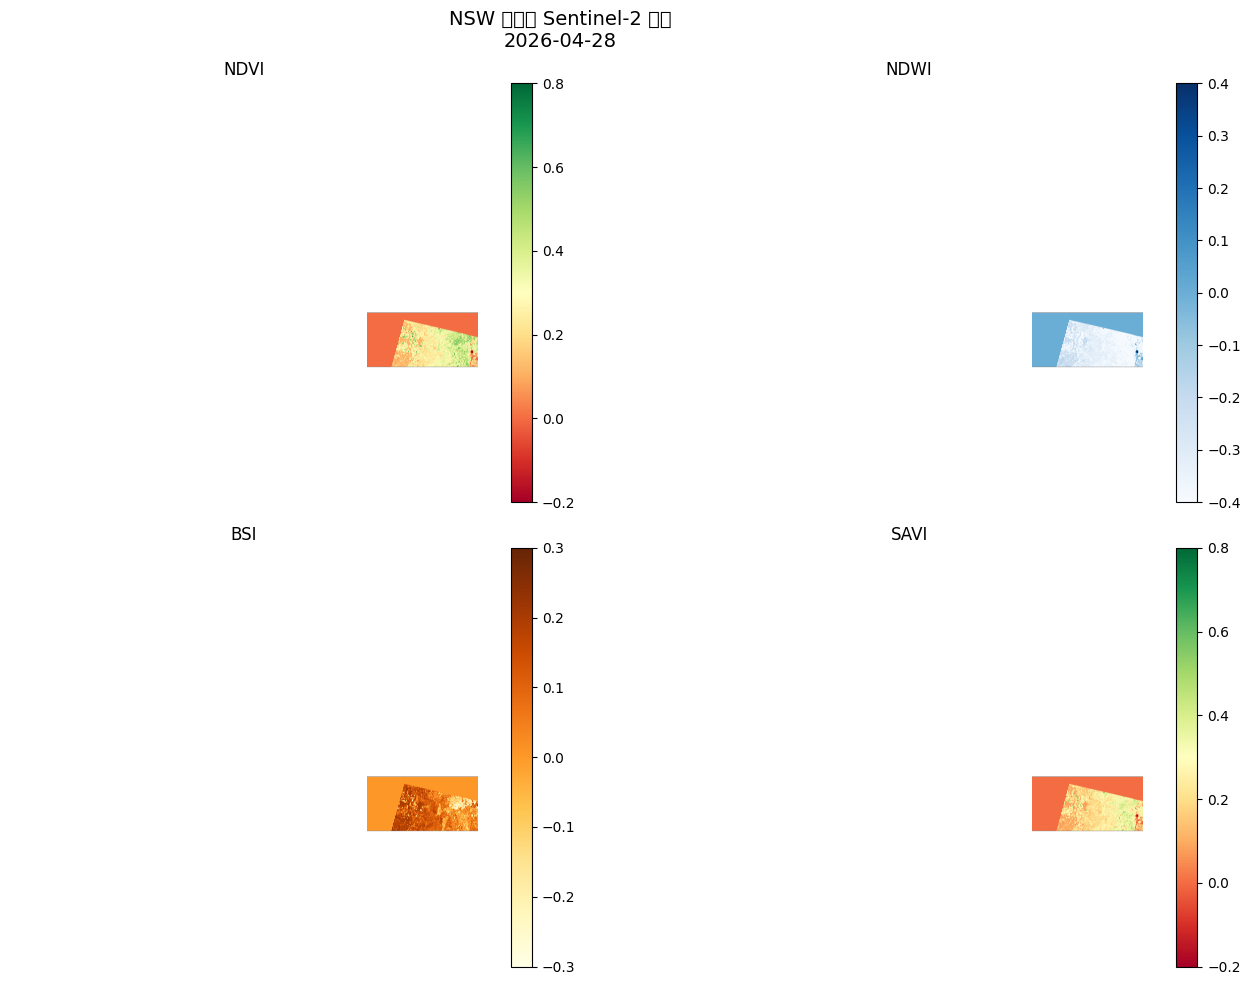

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'NSW 测试区 Sentinel-2 指数\n{best.datetime.strftime("%Y-%m-%d")}', 
             fontsize=14)

plots = [
    ('NDVI', indices['NDVI'], 'RdYlGn', -0.2, 0.8),
    ('NDWI', indices['NDWI'], 'Blues',  -0.4, 0.4),
    ('BSI',  indices['BSI'],  'YlOrBr', -0.3, 0.3),
    ('SAVI', indices['SAVI'], 'RdYlGn', -0.2, 0.8),
]

for ax, (name, arr, cmap, vmin, vmax) in zip(axes.flat, plots):
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()

fig_dir = ensure_dir('../results/figures')
fig_path = fig_dir / 'NSW_indices_2022_01.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'图像已保存: {fig_path}')
plt.show()

## 9. 保存为 GeoTIFF

In [26]:
raw_dir = ensure_dir('../data/raw/sentinel2')

# 获取空间参考信息
crs       = stack.crs
transform = stack.transform
height, width = B04.shape

# 保存各指数为 GeoTIFF
for name, arr in indices.items():
    out_path = raw_dir / f'NSW_test_{name}_2022_01.tif'
    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=height, width=width,
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(arr.astype('float32'), 1)
    print(f'已保存: {out_path}')

print('\n✓ 笔记本 01 完成')
print('下一步: 运行 02_feature_engineering.ipynb')

已保存: ..\data\raw\sentinel2\NSW_test_NDVI_2022_01.tif
已保存: ..\data\raw\sentinel2\NSW_test_NDWI_2022_01.tif
已保存: ..\data\raw\sentinel2\NSW_test_BSI_2022_01.tif
已保存: ..\data\raw\sentinel2\NSW_test_SAVI_2022_01.tif

✓ 笔记本 01 完成
下一步: 运行 02_feature_engineering.ipynb


In [ ]:
import subprocess

commands = [
    ['git', 'add', 'notebooks/01_data_download.ipynb'],
    ['git', 'add', 'results/figures/NSW_indices_2022_01.png'],
    ['git', 'add', '.gitignore'],
    ['git', 'commit', '-m', 'fix: allow figures upload, add NSW indices visualization'],
    ['git', 'push']
]

for cmd in commands:
    result = subprocess.run(cmd, cwd='..', capture_output=True, text=True)
    print(' '.join(cmd))
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

git add notebooks/01_data_download.ipynb
git commit -m feat: complete notebook 01 - Sentinel-2 download via Planetary Computer
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean

git push
Everything up-to-date

